# Tarea 2: Aprendizaje Distribuido para Computer Vision

| Campo | Valor |
|---|---|
| **Estudiante** | Esteban Gutiérrez Saborío |
| **Carrera** | Bachillerato en Ingeniería en Ciencia de Datos |
| **Universidad** | Lead University |
| **Curso** | Computación Paralela y Distribuida (TTCT0017) |
| **Profesor** | Johansell Villalobos Cubillo |
| **Fecha de entrega** | 11 de junio, 2026 |


## Índice

1. [Configuración del Entorno](#1-configuracion)
2. [Carga y Preprocesamiento del Dataset](#2-dataset)
3. [Implementación del Modelo CNN con Flax NNX](#3-modelo)
4. [Entrenamiento Base](#4-entrenamiento)
5. [Experimento 1: Impacto del Tamaño de Lote](#5-batch)
6. [Experimento 2: Impacto de la Tasa de Aprendizaje](#6-lr)
7. [Experimento 3: Impacto del Tamaño de la Red](#7-red)
8. [Optimización de Hiperparámetros](#8-hiperparam)
9. [Análisis de Precisión Numérica](#9-precision)
10. [Análisis y Discusión](#10-discusion)


---
## 1. Configuración del Entorno <a id='1-configuracion'></a>


In [ ]:
# Instalar dependencias necesarias
# Ejecutar solo si se usa Google Colab
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip install -q jax[cuda12] flax optax matplotlib scikit-learn pillow tqdm
else:
    # Entorno local (macOS Apple Silicon)
    # pip install jax-metal flax optax matplotlib scikit-learn pillow tqdm
    pass

In [ ]:
# ============================================================
# Importaciones
# Estudiante: Esteban Gutiérrez Saborío
# Curso: Computación Paralela y Distribuida (TTCT0017)
# Profesor: Johansell Villalobos Cubillo
# Fecha: 11 de junio, 2026
# ============================================================

import os
import time
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import defaultdict
from PIL import Image
from tqdm.auto import tqdm

import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, random as jax_random

import flax
from flax import nnx

import optax
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print(f"JAX version: {jax.__version__}")
print(f"Flax version: {flax.__version__}")
print(f"Optax version: {optax.__version__}")

JAX version: 0.7.2
Flax version: 0.11.2
Optax version: 0.2.8


In [ ]:
# ============================================================
# Verificar dispositivos disponibles
# ============================================================
print("Dispositivos disponibles:")
print(jax.devices())
print(f"Número de dispositivos: {jax.device_count()}")
print(f"Backend: {jax.default_backend()}")

# Semilla global para reproducibilidad
SEED = 42
key = jax_random.PRNGKey(SEED)
np.random.seed(SEED)
random.seed(SEED)

Dispositivos disponibles:
[CudaDevice(id=0)]
Número de dispositivos: 1
Backend: gpu


---
## 2. Carga y Preprocesamiento del Dataset <a id='2-dataset'></a>


In [6]:
# ============================================================
# SUBIR EL DATASET A GOOGLE COLAB
# Ejecuta UNO de los tres bloques siguientes según tu caso
# ============================================================

import os, zipfile
from pathlib import Path

if IN_COLAB:
    # ──────────────────────────────────────────────────────
    # MÉTODO 1 (recomendado): Subir el ZIP desde tu Mac
    # Paso 1: En tu Mac, abre Finder → busca la carpeta 'archive'
    #         → clic derecho → Comprimir → se crea archive.zip
    # Paso 2: Descomenta las 3 líneas de abajo y ejecuta esta celda
    # ──────────────────────────────────────────────────────
    from google.colab import files
    print('Selecciona el archivo archive.zip en el cuadro de carga...')
    uploaded = files.upload()
    if uploaded:
        zip_name = list(uploaded.keys())[0]
        print(f'Descomprimiendo {zip_name}...')
        with zipfile.ZipFile(zip_name, 'r') as zf:
            zf.extractall('/content/')
        print('Listo!')

    # ──────────────────────────────────────────────────────
    # MÉTODO 2: Usar Google Drive (si ya tienes el dataset ahí)
    # Descomenta las 2 líneas siguientes:
    # ──────────────────────────────────────────────────────
    # from google.colab import drive
    # drive.mount('/content/drive')

    # ──────────────────────────────────────────────────────
    # Detección automática de la ruta del dataset
    # ──────────────────────────────────────────────────────
    DETECTED = None
    search_bases = ['/content', '/content/drive/MyDrive', '/content/drive/My Drive']

    for base in search_bases:
        if not os.path.isdir(base):
            continue
        for root, dirs, files_list in os.walk(base):
            valid_class_dirs = [
                d for d in dirs
                if len([f for f in os.listdir(os.path.join(root, d))
                         if f.lower().endswith(('.jpg','.jpeg','.png'))]) > 5
            ]
            if len(valid_class_dirs) >= 5:
                DETECTED = root
                break
        if DETECTED:
            break

    if DETECTED:
        print(f'Dataset encontrado en: {DETECTED}')
        print(f'Clases: {sorted(valid_class_dirs)[:4]}...')
    else:
        print('No se encontro el dataset todavia.')
        print('Asegurate de haber subido el ZIP antes de ejecutar esta celda.')

else:
    DETECTED = None
    print('Entorno local — la ruta se configura en la siguiente celda.')

Selecciona el archivo archive.zip en el cuadro de carga...


Saving archive.zip to archive.zip
Descomprimiendo archive.zip...
Listo!
Dataset encontrado en: /content/archive/Wonders of World/Wonders of World
Clases: ['burj_khalifa', 'chichen_itza', 'christ_the_reedemer', 'eiffel_tower']...


In [7]:
# ============================================================
# Configuración del Dataset
# Wonders of the World Image Classification — 12 clases, ~3846 imágenes
# ============================================================

if IN_COLAB:
    if DETECTED:
        DATA_DIR = Path(DETECTED)
    else:
        # Ajusta esta ruta manualmente si la detección automática falló
        DATA_DIR = Path('/content/Wonders of World/Wonders of World')
else:
    DATA_DIR = Path('/Users/esteban07/Desktop/archive/Wonders of World/Wonders of World')

IMG_SIZE = (64, 64)       # Resolución de entrada
NUM_CHANNELS = 3          # RGB
BATCH_SIZE_DEFAULT = 64   # Tamaño de lote por defecto
NUM_EPOCHS = 15           # Épocas de entrenamiento base

assert DATA_DIR.exists(), (
    f'Dataset no encontrado en: {DATA_DIR}\n'
    'Sube el dataset según las instrucciones de la celda anterior.'
)

print(f'Dataset: {DATA_DIR}')
print(f'Clases encontradas: {sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])}')
print(f'Tamaño de imagen: {IMG_SIZE}')

Dataset: /content/archive/Wonders of World/Wonders of World
Clases encontradas: ['burj_khalifa', 'chichen_itza', 'christ_the_reedemer', 'eiffel_tower', 'great_wall_of_china', 'machu_pichu', 'pyramids_of_giza', 'roman_colosseum', 'statue_of_liberty', 'stonehenge', 'taj_mahal', 'venezuela_angel_falls']
Tamaño de imagen: (64, 64)


In [8]:
# ============================================================
# Cargar y preprocesar imágenes
# ============================================================

def load_dataset(data_dir: Path, img_size: tuple = (64, 64)) -> tuple:
    """
    Carga todas las imágenes desde el directorio organizado por clases.

    Args:
        data_dir: Directorio raíz con subcarpetas por clase
        img_size: Tupla (altura, ancho) para redimensionar

    Returns:
        X: Array numpy de imágenes normalizadas [N, H, W, C]
        y: Array numpy de etiquetas enteras
        class_names: Lista de nombres de clases
    """
    classes = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

    X, y = [], []
    class_counts = {}

    for cls in tqdm(classes, desc="Cargando clases"):
        cls_dir = data_dir / cls
        images = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.jpeg')) + list(cls_dir.glob('*.png'))
        class_counts[cls] = len(images)

        for img_path in images:
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize(img_size, Image.LANCZOS)
                img_array = np.array(img, dtype=np.float32)
                X.append(img_array)
                y.append(class_to_idx[cls])
            except Exception as e:
                pass  # Omitir imágenes corruptas

    X = np.array(X)
    y = np.array(y, dtype=np.int32)

    # Normalización: [0, 255] -> [0, 1]
    X = X / 255.0

    # Normalización por canal (media y std del dataset)
    mean = X.mean(axis=(0, 1, 2))
    std  = X.std(axis=(0, 1, 2))
    X = (X - mean) / (std + 1e-8)

    print(f"\nDataset cargado:")
    print(f"  Total de imágenes: {len(X)}")
    print(f"  Clases ({len(classes)}): {classes}")
    print(f"  Forma de X: {X.shape}")
    print(f"  Distribución por clase:")
    for cls, cnt in class_counts.items():
        print(f"    {cls}: {cnt} imágenes")

    return X, y, classes

X, y, CLASS_NAMES = load_dataset(DATA_DIR, IMG_SIZE)
NUM_CLASSES = len(CLASS_NAMES)

Cargando clases:   0%|          | 0/12 [00:00<?, ?it/s]


Dataset cargado:
  Total de imágenes: 3846
  Clases (12): ['burj_khalifa', 'chichen_itza', 'christ_the_reedemer', 'eiffel_tower', 'great_wall_of_china', 'machu_pichu', 'pyramids_of_giza', 'roman_colosseum', 'statue_of_liberty', 'stonehenge', 'taj_mahal', 'venezuela_angel_falls']
  Forma de X: (3846, 64, 64, 3)
  Distribución por clase:
    burj_khalifa: 390 imágenes
    chichen_itza: 340 imágenes
    christ_the_reedemer: 323 imágenes
    eiffel_tower: 391 imágenes
    great_wall_of_china: 392 imágenes
    machu_pichu: 393 imágenes
    pyramids_of_giza: 372 imágenes
    roman_colosseum: 394 imágenes
    statue_of_liberty: 238 imágenes
    stonehenge: 204 imágenes
    taj_mahal: 158 imágenes
    venezuela_angel_falls: 251 imágenes


In [9]:
# ============================================================
# Construcción de conjuntos de entrenamiento, validación y prueba
# Split: 70% train | 15% val | 15% test
# ============================================================

# Primera división: train (70%) + temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

# Segunda división: val (15%) + test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Conjuntos de datos:")
print(f"  Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validación:    {X_val.shape[0]} muestras ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Prueba:        {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")

Conjuntos de datos:
  Entrenamiento: 2692 muestras (70.0%)
  Validación:    577 muestras (15.0%)
  Prueba:        577 muestras (15.0%)


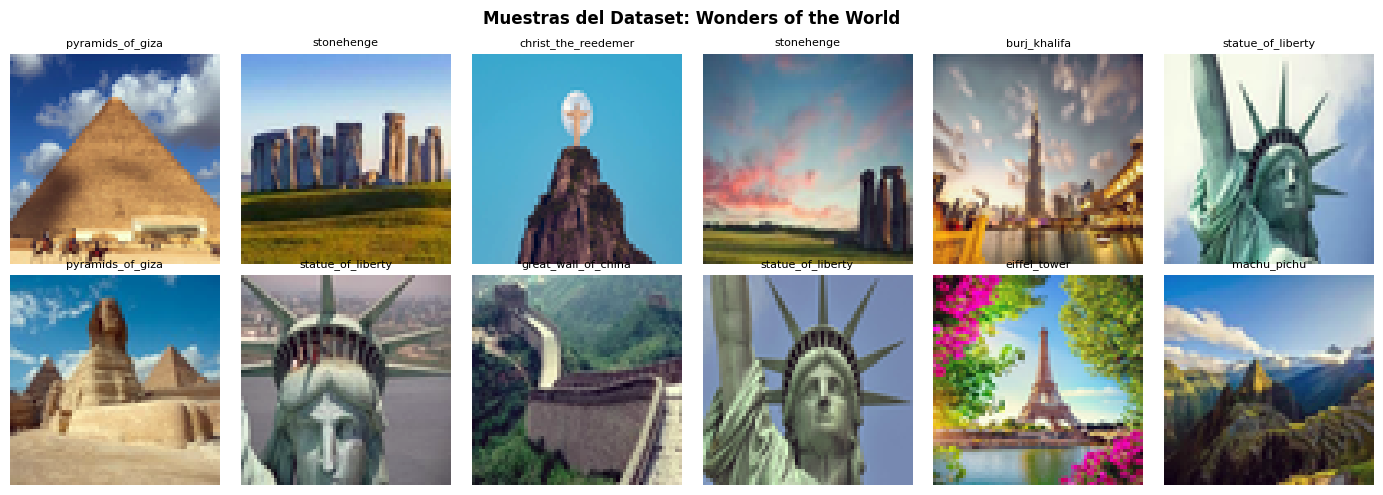

Figura guardada: samples_dataset.png


In [10]:
# ============================================================
# Pipeline de datos eficiente (generador de batches)
# ============================================================

def create_batches(X: np.ndarray, y: np.ndarray, batch_size: int,
                   shuffle: bool = True, rng_key=None) -> list:
    """
    Genera batches para alimentar el acelerador durante el entrenamiento.

    Args:
        X: Imágenes [N, H, W, C]
        y: Etiquetas [N]
        batch_size: Tamaño de cada batch
        shuffle: Si mezclar los datos
        rng_key: Clave JAX para reproducibilidad

    Returns:
        Lista de tuplas (X_batch, y_batch)
    """
    n = len(X)
    indices = np.arange(n)

    if shuffle:
        np.random.shuffle(indices)

    batches = []
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch_idx = indices[start:end]
        batches.append((
            jnp.array(X[batch_idx]),
            jnp.array(y[batch_idx])
        ))

    return batches


def visualize_samples(X: np.ndarray, y: np.ndarray,
                      class_names: list, n_samples: int = 12):
    """Visualiza muestras representativas del dataset."""
    fig, axes = plt.subplots(2, 6, figsize=(14, 5))
    indices = np.random.choice(len(X), n_samples, replace=False)

    for idx, ax in zip(indices, axes.flat):
        # Des-normalizar para visualizar
        img = X[idx]
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        ax.imshow(img)
        ax.set_title(class_names[y[idx]], fontsize=8)
        ax.axis('off')

    plt.suptitle('Muestras del Dataset: Wonders of the World', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('samples_dataset.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Figura guardada: samples_dataset.png")

visualize_samples(X_train, y_train, CLASS_NAMES)

---
## 3. Implementación del Modelo CNN con Flax NNX <a id='3-modelo'></a>


In [11]:
# ============================================================
# Modelo CNN con Flax NNX
# Arquitectura: Conv→BN→ReLU→MaxPool (×3) → Dense → Output
# ============================================================

class CNN(nnx.Module):
    """
    Red Neuronal Convolucional para clasificación de imágenes.

    Arquitectura:
        Conv(filters1) → BatchNorm → ReLU → MaxPool
        Conv(filters2) → BatchNorm → ReLU → MaxPool
        Conv(filters3) → BatchNorm → ReLU → MaxPool
        Flatten
        Dense(dense_units) → ReLU → Dropout
        Dense(num_classes)
    """

    def __init__(self,
                 num_classes: int,
                 filters: tuple = (32, 64, 128),
                 dense_units: int = 256,
                 dropout_rate: float = 0.4,
                 rngs: nnx.Rngs = None):
        """
        Args:
            num_classes: Número de clases de salida
            filters: Tupla con número de filtros por bloque convolucional
            dense_units: Neuronas en la capa densa oculta
            dropout_rate: Tasa de dropout
            rngs: Claves de aleatoriedad de Flax NNX
        """
        if rngs is None:
            rngs = nnx.Rngs(0)

        self.dropout_rate = dropout_rate

        # Bloque 1
        self.conv1 = nnx.Conv(in_features=3, out_features=filters[0],
                               kernel_size=(3, 3), padding='SAME', rngs=rngs)
        self.bn1   = nnx.BatchNorm(num_features=filters[0], rngs=rngs)

        # Bloque 2
        self.conv2 = nnx.Conv(in_features=filters[0], out_features=filters[1],
                               kernel_size=(3, 3), padding='SAME', rngs=rngs)
        self.bn2   = nnx.BatchNorm(num_features=filters[1], rngs=rngs)

        # Bloque 3
        self.conv3 = nnx.Conv(in_features=filters[1], out_features=filters[2],
                               kernel_size=(3, 3), padding='SAME', rngs=rngs)
        self.bn3   = nnx.BatchNorm(num_features=filters[2], rngs=rngs)

        # Calcular tamaño de aplanado: img_size / (2^3) por los 3 MaxPool
        # Para IMG_SIZE=(64,64): 64/8=8, entonces 8*8*filters[2]
        spatial = IMG_SIZE[0] // 8  # 3 maxpool de stride 2
        flat_size = spatial * spatial * filters[2]

        # Capas densas
        self.dense1  = nnx.Linear(in_features=flat_size,
                                   out_features=dense_units, rngs=rngs)
        self.dropout = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.dense2  = nnx.Linear(in_features=dense_units,
                                   out_features=num_classes, rngs=rngs)

    def __call__(self, x: jnp.ndarray, training: bool = True) -> jnp.ndarray:
        """
        Forward pass del modelo.

        Args:
            x: Batch de imágenes [B, H, W, C]
            training: Modo entrenamiento (activa BatchNorm y Dropout)
        """
        # Bloque 1: Conv → BN → ReLU → MaxPool
        x = self.conv1(x)
        x = self.bn1(x, use_running_average=not training)
        x = nnx.relu(x)
        x = nnx.max_pool(x, window_shape=(2, 2), strides=(2, 2), padding='VALID')

        # Bloque 2: Conv → BN → ReLU → MaxPool
        x = self.conv2(x)
        x = self.bn2(x, use_running_average=not training)
        x = nnx.relu(x)
        x = nnx.max_pool(x, window_shape=(2, 2), strides=(2, 2), padding='VALID')

        # Bloque 3: Conv → BN → ReLU → MaxPool
        x = self.conv3(x)
        x = self.bn3(x, use_running_average=not training)
        x = nnx.relu(x)
        x = nnx.max_pool(x, window_shape=(2, 2), strides=(2, 2), padding='VALID')

        # Aplanado
        x = x.reshape(x.shape[0], -1)

        # Capas densas
        x = self.dense1(x)
        x = nnx.relu(x)
        x = self.dropout(x, deterministic=not training)
        x = self.dense2(x)

        return x  # logits (sin softmax)


# Instanciar modelo por defecto para verificar arquitectura
model = CNN(num_classes=NUM_CLASSES,
            filters=(32, 64, 128),
            dense_units=256,
            rngs=nnx.Rngs(SEED))

# Verificar forward pass
dummy_input = jnp.ones((4, IMG_SIZE[0], IMG_SIZE[1], NUM_CHANNELS))
dummy_output = model(dummy_input, training=False)
print(f"Input shape:  {dummy_input.shape}")
print(f"Output shape: {dummy_output.shape}")
print(f"Número de clases: {dummy_output.shape[-1]}")
print("Arquitectura CNN verificada correctamente.")

Input shape:  (4, 64, 64, 3)
Output shape: (4, 12)
Número de clases: 12
Arquitectura CNN verificada correctamente.


---
## 4. Entrenamiento Base <a id='4-entrenamiento'></a>


In [16]:
# ============================================================
# Funciones de entrenamiento con JAX JIT
# ============================================================

def cross_entropy_loss(logits: jnp.ndarray, labels: jnp.ndarray) -> jnp.ndarray:
    """Función de pérdida: Entropía cruzada categórica."""
    log_probs = jax.nn.log_softmax(logits, axis=-1)
    one_hot   = jax.nn.one_hot(labels, logits.shape[-1])
    loss      = -jnp.sum(one_hot * log_probs, axis=-1)
    return jnp.mean(loss)


def compute_accuracy(logits: jnp.ndarray, labels: jnp.ndarray) -> float:
    """Calcula la exactitud de clasificación."""
    predictions = jnp.argmax(logits, axis=-1)
    return jnp.mean(predictions == labels)


@nnx.jit
def train_step(model: CNN, optimizer: nnx.Optimizer,
               X_batch: jnp.ndarray, y_batch: jnp.ndarray):
    """Un paso de entrenamiento compilado con JIT."""
    def loss_fn(model):
        logits = model(X_batch, training=True)
        return cross_entropy_loss(logits, y_batch)

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model: CNN, X_batch: jnp.ndarray, y_batch: jnp.ndarray):
    """Paso de evaluación compilado con JIT."""
    logits = model(X_batch, training=False)
    loss   = cross_entropy_loss(logits, y_batch)
    acc    = compute_accuracy(logits, y_batch)
    return loss, acc


def evaluate(model: CNN, X: np.ndarray, y: np.ndarray,
             batch_size: int = 128) -> tuple:
    """Evalúa el modelo sobre un conjunto completo."""
    batches = create_batches(X, y, batch_size, shuffle=False)
    total_loss, total_acc, total_n = 0.0, 0.0, 0

    for X_b, y_b in batches:
        n = len(y_b)
        loss, acc = eval_step(model, X_b, y_b)
        total_loss += float(loss) * n
        total_acc  += float(acc) * n
        total_n    += n

    return total_loss / total_n, total_acc / total_n


def train_model(config: dict,
                X_train=X_train, y_train=y_train,
                X_val=X_val, y_val=y_val,
                verbose: bool = True) -> dict:
    """Entrena el modelo con la configuración dada."""
    lr          = config.get('learning_rate', 1e-3)
    batch_size  = config.get('batch_size', 64)
    num_epochs  = config.get('num_epochs', NUM_EPOCHS)
    filters     = config.get('filters', (32, 64, 128))
    dense_units = config.get('dense_units', 256)

    mdl = CNN(num_classes=NUM_CLASSES, filters=filters,
              dense_units=dense_units, rngs=nnx.Rngs(SEED))

    steps_per_epoch = len(X_train) // batch_size
    total_steps     = num_epochs * steps_per_epoch
    schedule = optax.cosine_decay_schedule(
        init_value=lr, decay_steps=total_steps, alpha=0.1
    )
    optimizer = nnx.Optimizer(mdl, optax.adam(schedule), wrt=nnx.Param)

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss':   [], 'val_acc': [],
        'epoch_times': []
    }

    total_start = time.time()

    for epoch in range(num_epochs):
        epoch_start = time.time()
        batches = create_batches(X_train, y_train, batch_size, shuffle=True)

        epoch_loss = 0.0
        for X_b, y_b in batches:
            loss = train_step(mdl, optimizer, X_b, y_b)
            epoch_loss += float(loss)

        epoch_loss /= len(batches)
        epoch_time  = time.time() - epoch_start

        _, train_acc = evaluate(mdl, X_train, y_train, batch_size=128)
        val_loss, val_acc = evaluate(mdl, X_val, y_val, batch_size=128)

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(float(train_acc))
        history['val_loss'].append(float(val_loss))
        history['val_acc'].append(float(val_acc))
        history['epoch_times'].append(epoch_time)

        if verbose and (epoch + 1) % 5 == 0:
            print(f"  Época {epoch+1:3d}/{num_epochs} | "
                  f"Loss: {epoch_loss:.4f} | "
                  f"Train Acc: {train_acc:.4f} | "
                  f"Val Acc: {val_acc:.4f} | "
                  f"Tiempo: {epoch_time:.2f}s")

    total_time = time.time() - total_start

    test_loss, test_acc = evaluate(mdl, X_test, y_test, batch_size=128)
    throughput = (len(X_train) * num_epochs) / total_time

    results = {
        'model':          mdl,
        'history':        history,
        'total_time':     total_time,
        'avg_epoch_time': np.mean(history['epoch_times']),
        'throughput':     throughput,
        'final_train_acc': history['train_acc'][-1],
        'final_val_acc':   history['val_acc'][-1],
        'test_acc':       float(test_acc),
        'test_loss':      float(test_loss),
        'config':         config
    }

    if verbose:
        print(f"\n{'='*60}")
        print(f"Entrenamiento completado:")
        print(f"  Tiempo total:          {total_time:.2f}s")
        print(f"  Tiempo promedio/época: {results['avg_epoch_time']:.2f}s")
        print(f"  Throughput:            {throughput:.1f} img/s")
        print(f"  Exactitud train:       {history['train_acc'][-1]:.4f}")
        print(f"  Exactitud val:         {history['val_acc'][-1]:.4f}")
        print(f"  Exactitud test:        {test_acc:.4f}")
        print(f"{'='*60}")

    return results


print("Funciones de entrenamiento definidas.")
print("Compilación JIT activa: nnx.jit en train_step y eval_step")

Funciones de entrenamiento definidas.
Compilación JIT activa: nnx.jit en train_step y eval_step


In [17]:
# ============================================================
# Entrenamiento base
# ============================================================
print("Iniciando entrenamiento base...")
print(f"Configuración: lr=1e-3, batch=64, epochs={NUM_EPOCHS}, filters=(32,64,128), dense=256")
print()

baseline_config = {
    'learning_rate': 1e-3,
    'batch_size':    64,
    'num_epochs':    NUM_EPOCHS,
    'filters':       (32, 64, 128),
    'dense_units':   256
}

baseline_results = train_model(baseline_config)

Iniciando entrenamiento base...
Configuración: lr=1e-3, batch=64, epochs=15, filters=(32,64,128), dense=256

  Época   5/15 | Loss: 1.3274 | Train Acc: 0.6363 | Val Acc: 0.5685 | Tiempo: 0.52s
  Época  10/15 | Loss: 0.7894 | Train Acc: 0.8622 | Val Acc: 0.7366 | Tiempo: 0.52s
  Época  15/15 | Loss: 0.5650 | Train Acc: 0.9346 | Val Acc: 0.7816 | Tiempo: 0.55s

Entrenamiento completado:
  Tiempo total:          20.85s
  Tiempo promedio/época: 1.05s
  Throughput:            1936.3 img/s
  Exactitud train:       0.9346
  Exactitud val:         0.7816
  Exactitud test:        0.8146


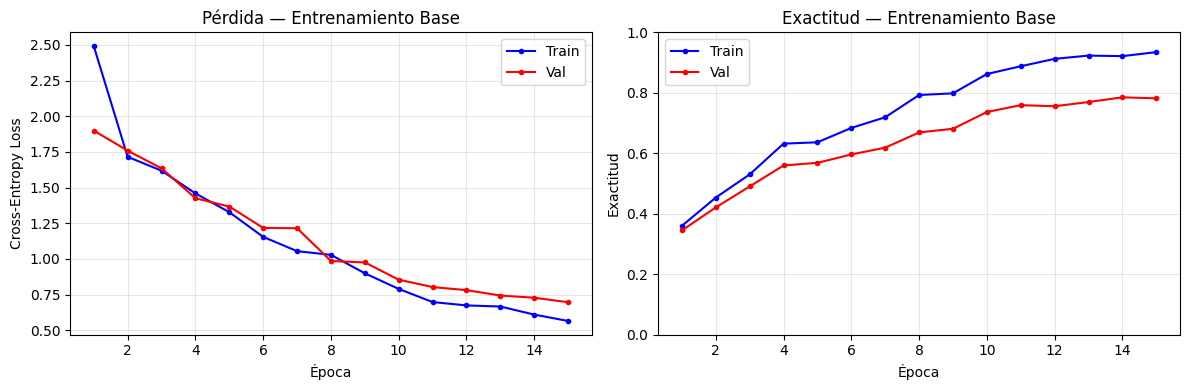

Figura guardada: 01_baseline_curves.png


In [18]:
# ============================================================
# Visualización curvas de pérdida y exactitud (entrenamiento base)
# ============================================================

def plot_training_curves(results: dict, title: str = 'Entrenamiento Base',
                         save_name: str = 'training_curves.png'):
    """Grafica curvas de pérdida y exactitud."""
    history = results['history']
    epochs  = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Pérdida
    axes[0].plot(epochs, history['train_loss'], 'b-o', markersize=3, label='Train')
    axes[0].plot(epochs, history['val_loss'],   'r-o', markersize=3, label='Val')
    axes[0].set_title(f'Pérdida — {title}')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Exactitud
    axes[1].plot(epochs, history['train_acc'], 'b-o', markersize=3, label='Train')
    axes[1].plot(epochs, history['val_acc'],   'r-o', markersize=3, label='Val')
    axes[1].set_title(f'Exactitud — {title}')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Exactitud')
    axes[1].set_ylim([0, 1])
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figura guardada: {save_name}")

plot_training_curves(baseline_results, title='Entrenamiento Base',
                     save_name='01_baseline_curves.png')

---
## 5. Experimento 1: Impacto del Tamaño de Lote <a id='5-batch'></a>


In [19]:
# ============================================================
# Experimento 1: Tamaños de lote 32, 64, 128
# ============================================================
print("\n" + "="*60)
print("EXPERIMENTO 1: Impacto del Tamaño de Lote")
print("="*60)

batch_sizes    = [32, 64, 128]
batch_results  = {}

for bs in batch_sizes:
    print(f"\n--- Batch size: {bs} ---")
    cfg = {
        'learning_rate': 1e-3,
        'batch_size':    bs,
        'num_epochs':    NUM_EPOCHS,
        'filters':       (32, 64, 128),
        'dense_units':   256
    }
    batch_results[bs] = train_model(cfg)


EXPERIMENTO 1: Impacto del Tamaño de Lote

--- Batch size: 32 ---
  Época   5/15 | Loss: 1.3570 | Train Acc: 0.6764 | Val Acc: 0.6170 | Tiempo: 0.64s
  Época  10/15 | Loss: 0.8337 | Train Acc: 0.8934 | Val Acc: 0.7418 | Tiempo: 0.71s
  Época  15/15 | Loss: 0.6065 | Train Acc: 0.9354 | Val Acc: 0.7834 | Tiempo: 0.65s

Entrenamiento completado:
  Tiempo total:          20.06s
  Tiempo promedio/época: 1.14s
  Throughput:            2013.2 img/s
  Exactitud train:       0.9354
  Exactitud val:         0.7834
  Exactitud test:        0.7920

--- Batch size: 64 ---
  Época   5/15 | Loss: 1.2317 | Train Acc: 0.5795 | Val Acc: 0.5165 | Tiempo: 0.52s
  Época  10/15 | Loss: 0.6903 | Train Acc: 0.8722 | Val Acc: 0.7383 | Tiempo: 0.52s
  Época  15/15 | Loss: 0.4724 | Train Acc: 0.9458 | Val Acc: 0.8007 | Tiempo: 0.52s

Entrenamiento completado:
  Tiempo total:          16.69s
  Tiempo promedio/época: 0.91s
  Throughput:            2419.9 img/s
  Exactitud train:       0.9458
  Exactitud val:     

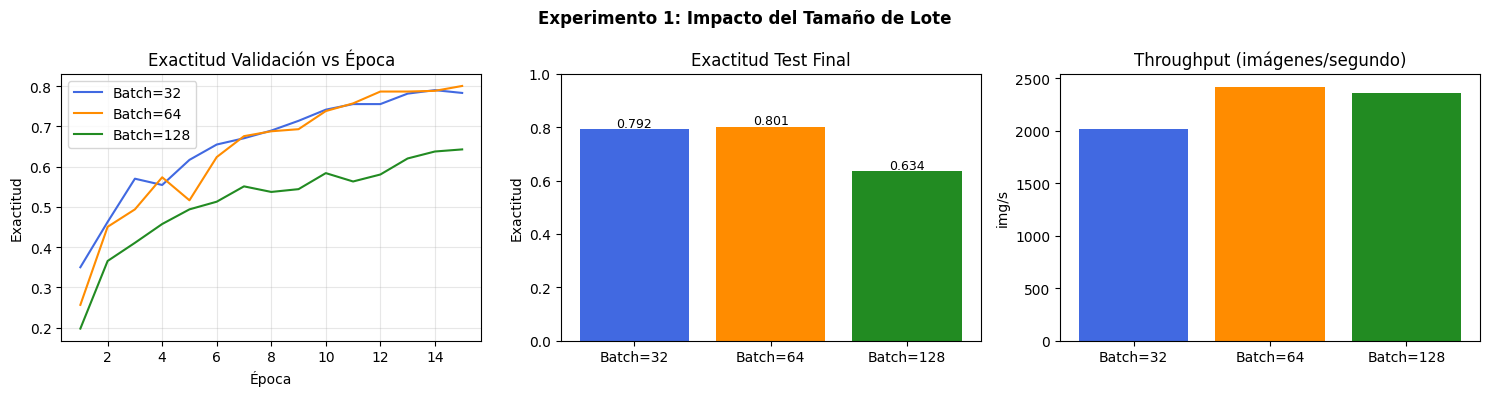


Resumen Experimento 1 — Tamaño de Lote
   Batch |  Tiempo(s) | Tpo/época(s) |  Test Acc |   Throughput
------------------------------------------------------------
      32 |      20.06 |         1.14 |    0.7920 |     2013.2 img/s
      64 |      16.69 |         0.91 |    0.8007 |     2419.9 img/s
     128 |      17.15 |         0.94 |    0.6343 |     2354.8 img/s


In [20]:
# Gráfica comparativa de tamaños de lote
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = ['royalblue', 'darkorange', 'forestgreen']
labels = [f'Batch={bs}' for bs in batch_sizes]

for i, (bs, color) in enumerate(zip(batch_sizes, colors)):
    res = batch_results[bs]
    epochs = range(1, len(res['history']['val_acc']) + 1)
    axes[0].plot(epochs, res['history']['val_acc'], color=color, label=labels[i])

axes[0].set_title('Exactitud Validación vs Época')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Exactitud')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Exactitud final vs batch size
final_accs = [batch_results[bs]['test_acc'] for bs in batch_sizes]
axes[1].bar(labels, final_accs, color=colors)
axes[1].set_title('Exactitud Test Final')
axes[1].set_ylabel('Exactitud')
axes[1].set_ylim([0, 1])
for j, v in enumerate(final_accs):
    axes[1].text(j, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

# Throughput vs batch size
throughputs = [batch_results[bs]['throughput'] for bs in batch_sizes]
axes[2].bar(labels, throughputs, color=colors)
axes[2].set_title('Throughput (imágenes/segundo)')
axes[2].set_ylabel('img/s')

plt.suptitle('Experimento 1: Impacto del Tamaño de Lote', fontweight='bold')
plt.tight_layout()
plt.savefig('02_batch_size_experiment.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen
print("\nResumen Experimento 1 — Tamaño de Lote")
print(f"{'Batch':>8} | {'Tiempo(s)':>10} | {'Tpo/época(s)':>12} | {'Test Acc':>9} | {'Throughput':>12}")
print("-" * 60)
for bs in batch_sizes:
    r = batch_results[bs]
    print(f"{bs:>8} | {r['total_time']:>10.2f} | {r['avg_epoch_time']:>12.2f} | "
          f"{r['test_acc']:>9.4f} | {r['throughput']:>10.1f} img/s")

---
## 6. Experimento 2: Impacto de la Tasa de Aprendizaje <a id='6-lr'></a>


In [21]:
# ============================================================
# Experimento 2: Tasas de aprendizaje 1e-2, 1e-3, 1e-4
# ============================================================
print("\n" + "="*60)
print("EXPERIMENTO 2: Impacto de la Tasa de Aprendizaje")
print("="*60)

learning_rates = [1e-2, 1e-3, 1e-4]
lr_results     = {}

for lr in learning_rates:
    print(f"\n--- Learning Rate: {lr:.0e} ---")
    cfg = {
        'learning_rate': lr,
        'batch_size':    64,
        'num_epochs':    NUM_EPOCHS,
        'filters':       (32, 64, 128),
        'dense_units':   256
    }
    lr_results[lr] = train_model(cfg)


EXPERIMENTO 2: Impacto de la Tasa de Aprendizaje

--- Learning Rate: 1e-02 ---
  Época   5/15 | Loss: 2.3282 | Train Acc: 0.2121 | Val Acc: 0.2045 | Tiempo: 0.52s
  Época  10/15 | Loss: 2.2703 | Train Acc: 0.2704 | Val Acc: 0.2548 | Tiempo: 0.59s
  Época  15/15 | Loss: 2.1545 | Train Acc: 0.3232 | Val Acc: 0.3033 | Tiempo: 0.52s

Entrenamiento completado:
  Tiempo total:          17.46s
  Tiempo promedio/época: 0.97s
  Throughput:            2312.1 img/s
  Exactitud train:       0.3232
  Exactitud val:         0.3033
  Exactitud test:        0.3310

--- Learning Rate: 1e-03 ---
  Época   5/15 | Loss: 1.3035 | Train Acc: 0.6096 | Val Acc: 0.5563 | Tiempo: 0.58s
  Época  10/15 | Loss: 0.8528 | Train Acc: 0.8718 | Val Acc: 0.7192 | Tiempo: 0.53s
  Época  15/15 | Loss: 0.6014 | Train Acc: 0.9316 | Val Acc: 0.7834 | Tiempo: 0.53s

Entrenamiento completado:
  Tiempo total:          16.31s
  Tiempo promedio/época: 0.89s
  Throughput:            2475.4 img/s
  Exactitud train:       0.9316
  

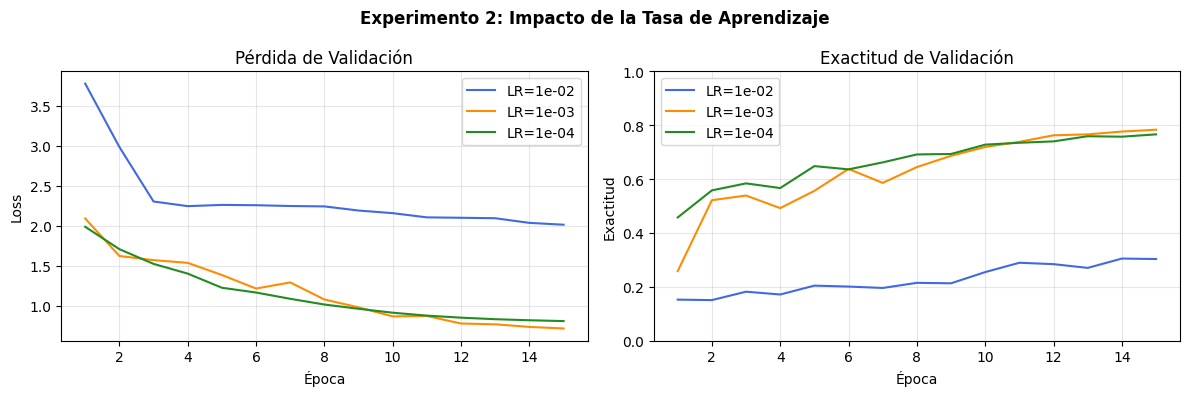


Resumen Experimento 2 — Tasa de Aprendizaje
      LR |  Test Acc |  Val Acc | Convergencia
--------------------------------------------------
   1e-02 |    0.3310 |   0.3033 | Estable
   1e-03 |    0.7972 |   0.7834 | Estable
   1e-04 |    0.7678 |   0.7660 | Estable


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['royalblue', 'darkorange', 'forestgreen']
lr_labels = [f'LR={lr:.0e}' for lr in learning_rates]

for i, (lr, color) in enumerate(zip(learning_rates, colors)):
    res = lr_results[lr]
    epochs = range(1, len(res['history']['val_loss']) + 1)
    axes[0].plot(epochs, res['history']['val_loss'], color=color, label=lr_labels[i])
    axes[1].plot(epochs, res['history']['val_acc'],  color=color, label=lr_labels[i])

axes[0].set_title('Pérdida de Validación'); axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Exactitud de Validación'); axes[1].set_xlabel('Época')
axes[1].set_ylabel('Exactitud'); axes[1].set_ylim([0, 1])
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Experimento 2: Impacto de la Tasa de Aprendizaje', fontweight='bold')
plt.tight_layout()
plt.savefig('03_learning_rate_experiment.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nResumen Experimento 2 — Tasa de Aprendizaje")
print(f"{'LR':>8} | {'Test Acc':>9} | {'Val Acc':>8} | {'Convergencia'}")
print("-" * 50)
for lr in learning_rates:
    r = lr_results[lr]
    val_accs = r['history']['val_acc']
    monotone = 'Estable' if val_accs[-1] > val_accs[0] else 'Inestable'
    print(f"{lr:>8.0e} | {r['test_acc']:>9.4f} | {r['final_val_acc']:>8.4f} | {monotone}")

---
## 7. Experimento 3: Impacto del Tamaño de la Red <a id='7-red'></a>


In [23]:
# ============================================================
# Experimento 3: Configuraciones de filtros y neuronas
# ============================================================
print("\n" + "="*60)
print("EXPERIMENTO 3: Impacto del Tamaño de la Red")
print("="*60)

network_configs = [
    {'name': 'Pequeña  (32f-128d)',  'filters': (16, 32, 64),   'dense_units': 128},
    {'name': 'Mediana  (64f-256d)',  'filters': (32, 64, 128),  'dense_units': 256},
    {'name': 'Grande   (128f-512d)', 'filters': (64, 128, 256), 'dense_units': 512},
]

net_results = {}
for nc in network_configs:
    print(f"\n--- {nc['name']} ---")
    cfg = {
        'learning_rate': 1e-3,
        'batch_size':    64,
        'num_epochs':    NUM_EPOCHS,
        'filters':       nc['filters'],
        'dense_units':   nc['dense_units']
    }
    net_results[nc['name']] = train_model(cfg)


EXPERIMENTO 3: Impacto del Tamaño de la Red

--- Pequeña  (32f-128d) ---
  Época   5/15 | Loss: 1.3005 | Train Acc: 0.6348 | Val Acc: 0.5615 | Tiempo: 0.33s
  Época  10/15 | Loss: 0.8997 | Train Acc: 0.8343 | Val Acc: 0.6898 | Tiempo: 0.37s
  Época  15/15 | Loss: 0.7445 | Train Acc: 0.9164 | Val Acc: 0.7608 | Tiempo: 0.33s

Entrenamiento completado:
  Tiempo total:          16.96s
  Tiempo promedio/época: 0.85s
  Throughput:            2381.3 img/s
  Exactitud train:       0.9164
  Exactitud val:         0.7608
  Exactitud test:        0.7834

--- Mediana  (64f-256d) ---
  Época   5/15 | Loss: 1.3046 | Train Acc: 0.5290 | Val Acc: 0.4835 | Tiempo: 0.59s
  Época  10/15 | Loss: 0.6826 | Train Acc: 0.8343 | Val Acc: 0.7002 | Tiempo: 0.53s
  Época  15/15 | Loss: 0.4828 | Train Acc: 0.9580 | Val Acc: 0.8111 | Tiempo: 0.53s

Entrenamiento completado:
  Tiempo total:          16.60s
  Tiempo promedio/época: 0.91s
  Throughput:            2432.1 img/s
  Exactitud train:       0.9580
  Exactit

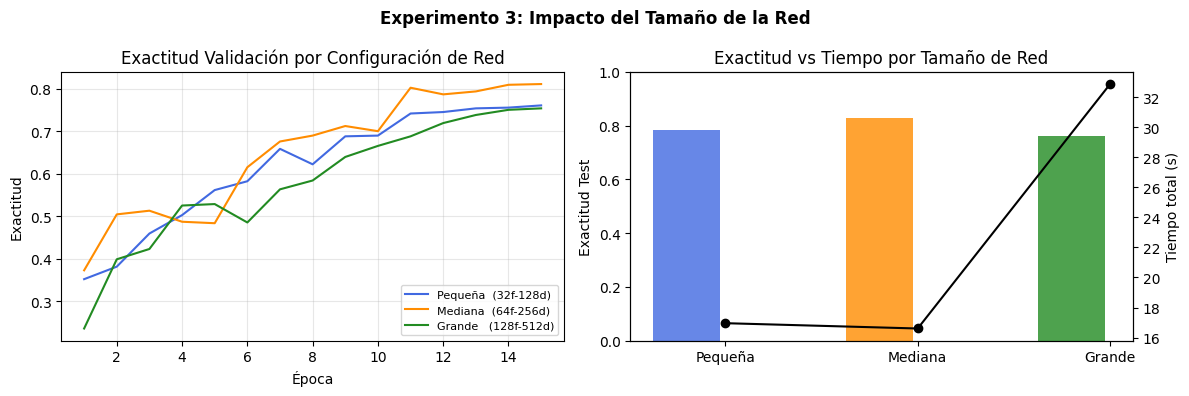


Resumen Experimento 3 — Tamaño de la Red
                   Config |  Test Acc |  Tiempo(s) |   Throughput
-----------------------------------------------------------------
      Pequeña  (32f-128d) |    0.7834 |      16.96 |     2381.3 img/s
      Mediana  (64f-256d) |    0.8284 |      16.60 |     2432.1 img/s
     Grande   (128f-512d) |    0.7608 |      32.87 |     1228.5 img/s


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['royalblue', 'darkorange', 'forestgreen']
net_names = [nc['name'] for nc in network_configs]

for i, (name, color) in enumerate(zip(net_names, colors)):
    res = net_results[name]
    epochs = range(1, len(res['history']['val_acc']) + 1)
    axes[0].plot(epochs, res['history']['val_acc'], color=color, label=name)

axes[0].set_title('Exactitud Validación por Configuración de Red')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Exactitud')
axes[0].legend(loc='lower right', fontsize=8); axes[0].grid(True, alpha=0.3)

accs   = [net_results[n]['test_acc']   for n in net_names]
times  = [net_results[n]['total_time'] for n in net_names]
short_names = ['Pequeña', 'Mediana', 'Grande']
x = np.arange(len(net_names))

ax2 = axes[1].twinx()
bars = axes[1].bar(x - 0.2, accs, 0.35, color=colors, alpha=0.8, label='Exactitud')
line = ax2.plot(x, times, 'k-o', label='Tiempo (s)')
axes[1].set_xticks(x); axes[1].set_xticklabels(short_names)
axes[1].set_ylabel('Exactitud Test'); ax2.set_ylabel('Tiempo total (s)')
axes[1].set_title('Exactitud vs Tiempo por Tamaño de Red')
axes[1].set_ylim([0, 1])

plt.suptitle('Experimento 3: Impacto del Tamaño de la Red', fontweight='bold')
plt.tight_layout()
plt.savefig('04_network_size_experiment.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nResumen Experimento 3 — Tamaño de la Red")
print(f"{'Config':>25} | {'Test Acc':>9} | {'Tiempo(s)':>10} | {'Throughput':>12}")
print("-" * 65)
for name in net_names:
    r = net_results[name]
    print(f"{name:>25} | {r['test_acc']:>9.4f} | {r['total_time']:>10.2f} | {r['throughput']:>10.1f} img/s")

---
## 8. Optimización de Hiperparámetros <a id='8-hiperparam'></a>


In [25]:
# ============================================================
# Búsqueda de Hiperparámetros (Random Search)
# Estrategia: Random Search sobre espacio definido
# ============================================================
print("\n" + "="*60)
print("OPTIMIZACIÓN DE HIPERPARÁMETROS — Random Search")
print("="*60)

# Espacio de búsqueda
search_space = {
    'learning_rate': [1e-2, 5e-3, 1e-3, 5e-4, 1e-4],
    'batch_size':    [32, 64, 128],
    'filters':       [(16, 32, 64), (32, 64, 128), (64, 128, 256)],
    'dense_units':   [128, 256, 512],
    'num_epochs':    [NUM_EPOCHS]
}

N_TRIALS = 8  # Número de configuraciones a evaluar
random.seed(SEED)

# Generar configuraciones aleatorias
trials = []
for i in range(N_TRIALS):
    cfg = {
        'learning_rate': random.choice(search_space['learning_rate']),
        'batch_size':    random.choice(search_space['batch_size']),
        'filters':       random.choice(search_space['filters']),
        'dense_units':   random.choice(search_space['dense_units']),
        'num_epochs':    NUM_EPOCHS
    }
    trials.append(cfg)

print(f"Evaluando {N_TRIALS} configuraciones aleatorias...\n")

hp_results = []
for i, cfg in enumerate(trials):
    print(f"Trial {i+1}/{N_TRIALS}: lr={cfg['learning_rate']:.0e}, "
          f"bs={cfg['batch_size']}, filters={cfg['filters']}, dense={cfg['dense_units']}")
    res = train_model(cfg, verbose=False)
    hp_results.append(res)
    print(f"  → Test Acc: {res['test_acc']:.4f} | Time: {res['total_time']:.1f}s | "
          f"Throughput: {res['throughput']:.0f} img/s")

# Ordenar por exactitud en test
hp_results_sorted = sorted(hp_results, key=lambda x: x['test_acc'], reverse=True)
best_config = hp_results_sorted[0]

print(f"\n{'='*60}")
print(f"MEJOR CONFIGURACIÓN:")
print(f"  Learning Rate: {best_config['config']['learning_rate']:.0e}")
print(f"  Batch Size:    {best_config['config']['batch_size']}")
print(f"  Filters:       {best_config['config']['filters']}")
print(f"  Dense Units:   {best_config['config']['dense_units']}")
print(f"  Test Accuracy: {best_config['test_acc']:.4f}")
print(f"  Throughput:    {best_config['throughput']:.1f} img/s")


OPTIMIZACIÓN DE HIPERPARÁMETROS — Random Search
Evaluando 8 configuraciones aleatorias...

Trial 1/8: lr=1e-02, bs=32, filters=(64, 128, 256), dense=256
  → Test Acc: 0.1906 | Time: 30.9s | Throughput: 1306 img/s
Trial 2/8: lr=5e-03, bs=32, filters=(16, 32, 64), dense=512
  → Test Acc: 0.6811 | Time: 17.5s | Throughput: 2302 img/s
Trial 3/8: lr=1e-02, bs=128, filters=(64, 128, 256), dense=512
  → Test Acc: 0.3085 | Time: 28.0s | Throughput: 1445 img/s
Trial 4/8: lr=1e-02, bs=128, filters=(32, 64, 128), dense=128
  → Test Acc: 0.1941 | Time: 17.7s | Throughput: 2288 img/s
Trial 5/8: lr=1e-02, bs=32, filters=(16, 32, 64), dense=128
  → Test Acc: 0.1023 | Time: 14.6s | Throughput: 2761 img/s
Trial 6/8: lr=1e-04, bs=128, filters=(16, 32, 64), dense=512
  → Test Acc: 0.6724 | Time: 12.9s | Throughput: 3140 img/s
Trial 7/8: lr=5e-03, bs=128, filters=(64, 128, 256), dense=512
  → Test Acc: 0.1733 | Time: 25.5s | Throughput: 1585 img/s
Trial 8/8: lr=1e-04, bs=64, filters=(16, 32, 64), dense=2


Tabla Completa — Random Search
  # |      LR |   BS |        Filters | Dense |  Test Acc |  Time(s) |    Thput
---------------------------------------------------------------------------
  1 |   1e-04 |   64 |   (16, 32, 64) |   256 |    0.7106 |     15.1 |   2669 img/s
  2 |   5e-03 |   32 |   (16, 32, 64) |   512 |    0.6811 |     17.5 |   2302 img/s
  3 |   1e-04 |  128 |   (16, 32, 64) |   512 |    0.6724 |     12.9 |   3140 img/s
  4 |   1e-02 |  128 | (64, 128, 256) |   512 |    0.3085 |     28.0 |   1445 img/s
  5 |   1e-02 |  128 |  (32, 64, 128) |   128 |    0.1941 |     17.7 |   2288 img/s
  6 |   1e-02 |   32 | (64, 128, 256) |   256 |    0.1906 |     30.9 |   1306 img/s
  7 |   5e-03 |  128 | (64, 128, 256) |   512 |    0.1733 |     25.5 |   1585 img/s
  8 |   1e-02 |   32 |   (16, 32, 64) |   128 |    0.1023 |     14.6 |   2761 img/s


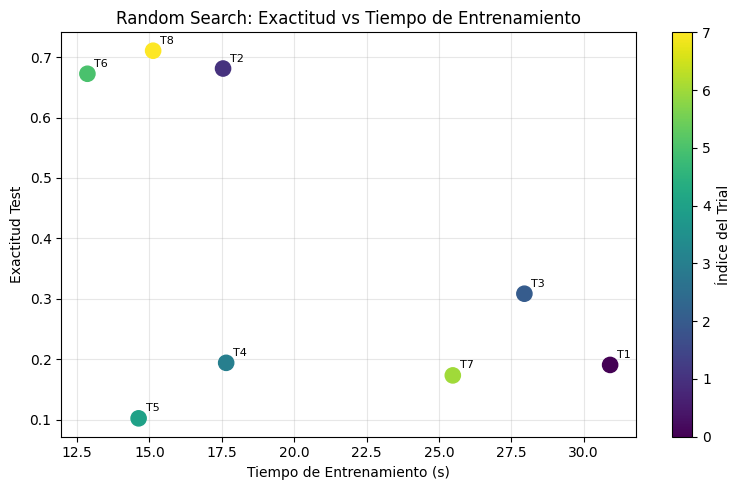

In [26]:
# Tabla completa de resultados del random search
print("\nTabla Completa — Random Search")
print(f"{'#':>3} | {'LR':>7} | {'BS':>4} | {'Filters':>14} | {'Dense':>5} | {'Test Acc':>9} | {'Time(s)':>8} | {'Thput':>8}")
print("-" * 75)
for i, (res, cfg_orig) in enumerate(zip(hp_results_sorted,
                                         [r['config'] for r in hp_results_sorted])):
    c = res['config']
    print(f"{i+1:>3} | {c['learning_rate']:>7.0e} | {c['batch_size']:>4} | "
          f"{str(c['filters']):>14} | {c['dense_units']:>5} | "
          f"{res['test_acc']:>9.4f} | {res['total_time']:>8.1f} | "
          f"{res['throughput']:>6.0f} img/s")

# Gráfica de dispersión: exactitud vs tiempo
fig, ax = plt.subplots(figsize=(8, 5))
accs_hp  = [r['test_acc'] for r in hp_results]
times_hp = [r['total_time'] for r in hp_results]
sc = ax.scatter(times_hp, accs_hp, c=range(len(hp_results)),
                cmap='viridis', s=120, zorder=5)
for i, (t, a) in enumerate(zip(times_hp, accs_hp)):
    ax.annotate(f'T{i+1}', (t, a), textcoords='offset points', xytext=(5, 5), fontsize=8)
ax.set_xlabel('Tiempo de Entrenamiento (s)')
ax.set_ylabel('Exactitud Test')
ax.set_title('Random Search: Exactitud vs Tiempo de Entrenamiento')
ax.grid(True, alpha=0.3)
plt.colorbar(sc, label='Índice del Trial')
plt.tight_layout()
plt.savefig('05_hyperparameter_search.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Análisis de Precisión Numérica <a id='9-precision'></a>


In [28]:
# ============================================================
# Análisis de Precisión Numérica: float32, float16, bfloat16
# ============================================================
print("\n" + "="*60)
print("ANÁLISIS DE PRECISIÓN NUMÉRICA")
print("="*60)

import tracemalloc

def train_with_dtype(dtype_name: str, config: dict) -> dict:
    """Entrena el modelo convirtiendo los datos al tipo especificado."""
    dtype_map = {
        'float32':  jnp.float32,
        'float16':  jnp.float16,
        'bfloat16': jnp.bfloat16
    }
    dtype = dtype_map[dtype_name]
    print(f"\n--- Tipo de dato: {dtype_name} ---")

    X_tr = jnp.array(X_train, dtype=dtype)
    X_vl = jnp.array(X_val,   dtype=dtype)
    X_ts = jnp.array(X_test,  dtype=dtype)

    mdl = CNN(num_classes=NUM_CLASSES, filters=config['filters'],
              dense_units=config['dense_units'], rngs=nnx.Rngs(SEED))

    bs = config['batch_size']
    steps_per_epoch = len(X_train) // bs
    total_steps     = config['num_epochs'] * steps_per_epoch
    schedule = optax.cosine_decay_schedule(
        init_value=config['learning_rate'], decay_steps=total_steps, alpha=0.1
    )
    optimizer = nnx.Optimizer(mdl, optax.adam(schedule), wrt=nnx.Param)

    nan_count    = 0
    inf_count    = 0
    epoch_losses = []

    tracemalloc.start()
    start = time.time()

    for epoch in range(config['num_epochs']):
        n = len(X_tr)
        indices = np.random.permutation(n)
        epoch_loss = 0.0
        n_batches  = 0

        for start_i in range(0, n, bs):
            end_i = min(start_i + bs, n)
            idx = indices[start_i:end_i]
            X_b = X_tr[idx]
            y_b = jnp.array(y_train[idx])

            loss = train_step(mdl, optimizer, X_b, y_b)
            lv = float(loss)

            if np.isnan(lv): nan_count += 1
            if np.isinf(lv): inf_count += 1
            epoch_loss += lv
            n_batches  += 1

        epoch_losses.append(epoch_loss / n_batches if n_batches else 0.0)

    total_time = time.time() - start
    _, mem_peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    batches_ts = [(X_ts[i:i+128], jnp.array(y_test[i:i+128]))
                  for i in range(0, len(X_ts), 128)]
    total_acc, total_n = 0.0, 0
    for X_b, y_b in batches_ts:
        logits = mdl(X_b, training=False)
        acc = float(compute_accuracy(logits, y_b))
        total_acc += acc * len(y_b)
        total_n   += len(y_b)
    test_acc = total_acc / total_n

    throughput = (len(X_train) * config['num_epochs']) / total_time

    result = {
        'dtype':        dtype_name,
        'test_acc':     test_acc,
        'total_time':   total_time,
        'throughput':   throughput,
        'nan_count':    nan_count,
        'inf_count':    inf_count,
        'mem_peak_mb':  mem_peak / 1e6,
        'epoch_losses': epoch_losses,
        'stable':       nan_count == 0 and inf_count == 0
    }

    print(f"  Test Acc: {test_acc:.4f} | Time: {total_time:.1f}s | "
          f"Throughput: {throughput:.0f} img/s | NaN: {nan_count} | "
          f"Inf: {inf_count} | Mem: {mem_peak/1e6:.1f} MB")

    return result


dtype_config = {
    'learning_rate': 1e-3,
    'batch_size':    64,
    'num_epochs':    NUM_EPOCHS,
    'filters':       (32, 64, 128),
    'dense_units':   256
}

dtype_results = {}
for dt in ['float32', 'float16', 'bfloat16']:
    dtype_results[dt] = train_with_dtype(dt, dtype_config)


ANÁLISIS DE PRECISIÓN NUMÉRICA

--- Tipo de dato: float32 ---
  Test Acc: 0.8232 | Time: 25.9s | Throughput: 1562 img/s | NaN: 0 | Inf: 0 | Mem: 3.6 MB

--- Tipo de dato: float16 ---
  Test Acc: 0.8284 | Time: 23.8s | Throughput: 1697 img/s | NaN: 0 | Inf: 0 | Mem: 3.2 MB

--- Tipo de dato: bfloat16 ---
  Test Acc: 0.8284 | Time: 24.0s | Throughput: 1683 img/s | NaN: 0 | Inf: 0 | Mem: 3.2 MB


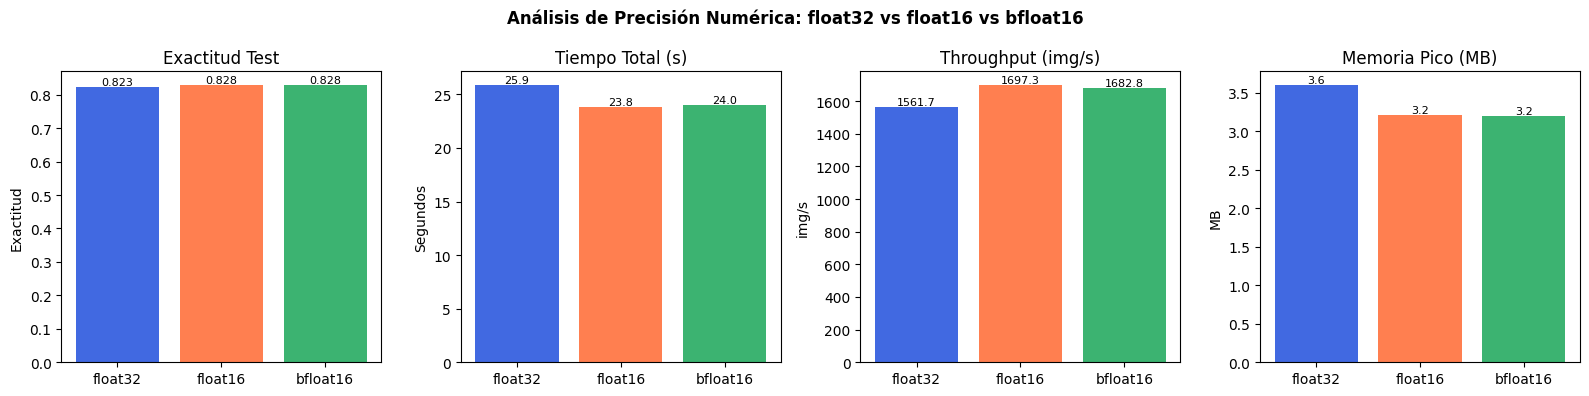

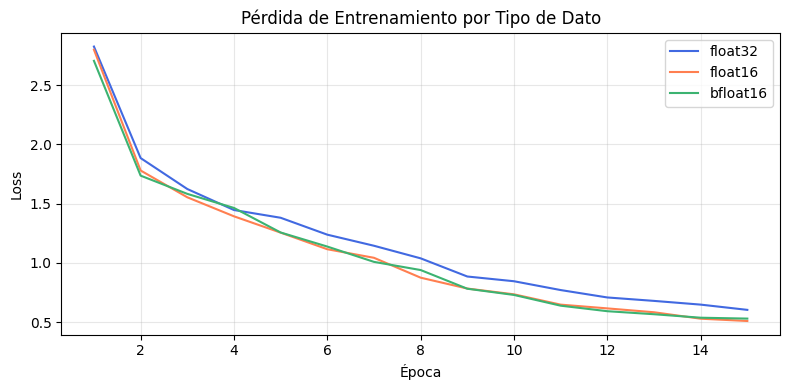


Tabla Resumen — Análisis de Precisión Numérica
      Tipo |  Test Acc |  Tiempo(s) |   Throughput |   Mem(MB) |  Estable |   NaN
---------------------------------------------------------------------------
   float32 |    0.8232 |      25.86 |     1561.7 img/s |       3.6 |     True |     0
   float16 |    0.8284 |      23.79 |     1697.3 img/s |       3.2 |     True |     0
  bfloat16 |    0.8284 |      24.00 |     1682.8 img/s |       3.2 |     True |     0


In [29]:
# Comparativa de precisión numérica
dtypes = ['float32', 'float16', 'bfloat16']
colors = ['royalblue', 'coral', 'mediumseagreen']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

accs_dt   = [dtype_results[d]['test_acc']   for d in dtypes]
times_dt  = [dtype_results[d]['total_time'] for d in dtypes]
thpts_dt  = [dtype_results[d]['throughput'] for d in dtypes]
mems_dt   = [dtype_results[d]['mem_peak_mb'] for d in dtypes]

for ax, vals, title, ylabel in zip(
        axes,
        [accs_dt, times_dt, thpts_dt, mems_dt],
        ['Exactitud Test', 'Tiempo Total (s)', 'Throughput (img/s)', 'Memoria Pico (MB)'],
        ['Exactitud', 'Segundos', 'img/s', 'MB']):
    bars = ax.bar(dtypes, vals, color=colors)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}' if val < 2 else f'{val:.1f}',
                ha='center', va='bottom', fontsize=8)

plt.suptitle('Análisis de Precisión Numérica: float32 vs float16 vs bfloat16',
             fontweight='bold')
plt.tight_layout()
plt.savefig('06_numerical_precision.png', dpi=150, bbox_inches='tight')
plt.show()

# Curvas de pérdida por tipo
fig, ax = plt.subplots(figsize=(8, 4))
for dt, color in zip(dtypes, colors):
    losses = dtype_results[dt]['epoch_losses']
    ax.plot(range(1, len(losses)+1), losses, color=color, label=dt)
ax.set_title('Pérdida de Entrenamiento por Tipo de Dato')
ax.set_xlabel('Época'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('06b_precision_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen
print("\nTabla Resumen — Análisis de Precisión Numérica")
print(f"{'Tipo':>10} | {'Test Acc':>9} | {'Tiempo(s)':>10} | {'Throughput':>12} | {'Mem(MB)':>9} | {'Estable':>8} | {'NaN':>5}")
print("-" * 75)
for dt in dtypes:
    r = dtype_results[dt]
    print(f"{dt:>10} | {r['test_acc']:>9.4f} | {r['total_time']:>10.2f} | "
          f"{r['throughput']:>10.1f} img/s | {r['mem_peak_mb']:>9.1f} | "
          f"{str(r['stable']):>8} | {r['nan_count']:>5}")

---
## 10. Análisis y Discusión <a id='10-discusion'></a>


Reporte de Clasificación (Mejor Modelo):
                       precision    recall  f1-score   support

         burj_khalifa       0.65      0.71      0.68        59
         chichen_itza       0.75      0.65      0.69        51
  christ_the_reedemer       0.61      0.62      0.62        48
         eiffel_tower       0.66      0.64      0.65        59
  great_wall_of_china       0.59      0.73      0.65        59
          machu_pichu       0.78      0.78      0.78        59
     pyramids_of_giza       0.80      0.93      0.86        56
      roman_colosseum       0.82      0.83      0.82        59
    statue_of_liberty       0.80      0.56      0.66        36
           stonehenge       0.83      0.65      0.73        31
            taj_mahal       0.56      0.39      0.46        23
venezuela_angel_falls       0.72      0.76      0.74        37

             accuracy                           0.71       577
            macro avg       0.71      0.69      0.69       577
         wei

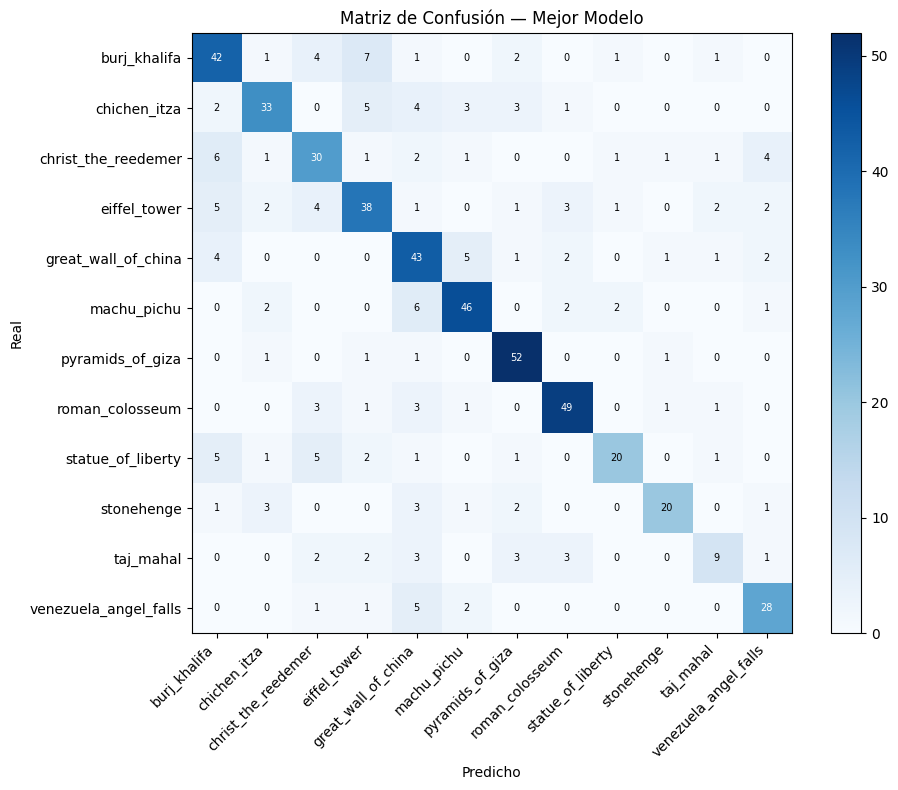

In [30]:
# ============================================================
# Evaluación final del mejor modelo
# ============================================================

best_model = best_config['model']

# Predicciones en test
all_preds, all_labels = [], []
for X_b, y_b in create_batches(X_test, y_test, 128, shuffle=False):
    logits = best_model(X_b, training=False)
    preds  = jnp.argmax(logits, axis=-1)
    all_preds.extend(np.array(preds))
    all_labels.extend(np.array(y_b))

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("Reporte de Clasificación (Mejor Modelo):")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASS_NAMES))); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticks(range(len(CLASS_NAMES))); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión — Mejor Modelo')
plt.colorbar(im)
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=7)
plt.tight_layout()
plt.savefig('07_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

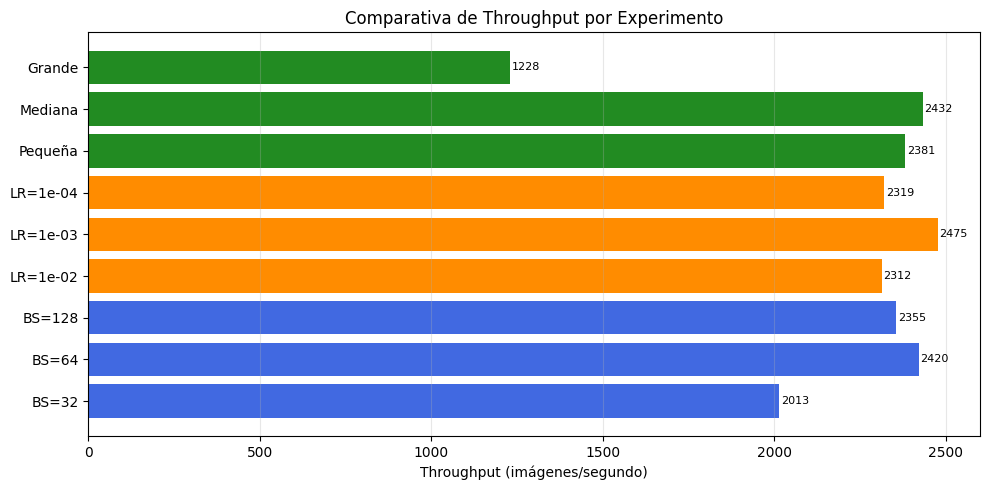

In [31]:
# ============================================================
# Gráfica de Throughput Comparativo (todos los experimentos)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

all_labels_tp = []
all_throughputs = []

for bs in batch_sizes:
    all_labels_tp.append(f'BS={bs}')
    all_throughputs.append(batch_results[bs]['throughput'])

for lr in learning_rates:
    all_labels_tp.append(f'LR={lr:.0e}')
    all_throughputs.append(lr_results[lr]['throughput'])

for name in net_names:
    all_labels_tp.append(name.split('(')[0].strip())
    all_throughputs.append(net_results[name]['throughput'])

colors_tp = (['royalblue']*3 + ['darkorange']*3 + ['forestgreen']*3)
bars = ax.barh(all_labels_tp, all_throughputs, color=colors_tp)
for bar, val in zip(bars, all_throughputs):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=8)

ax.set_xlabel('Throughput (imágenes/segundo)')
ax.set_title('Comparativa de Throughput por Experimento')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('08_throughput_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
### Análisis y Discusión — Respuestas

**1. ¿Qué ventajas ofrece Flax NNX respecto a implementar modelos directamente en JAX?**

Flax NNX proporciona abstracciones de alto nivel que simplifican la gestión del estado del modelo (parámetros, estadísticas de BatchNorm) mediante el uso de objetos mutables. A diferencia de JAX puro —que requiere manejar manualmente los parámetros como árboles pytree y el estado mutable de capas como BatchNorm— NNX encapsula todo en módulos orientados a objetos similares a PyTorch, reduciendo la complejidad del código y el riesgo de errores. Además, NNX integra `nnx.jit` y `nnx.value_and_grad` que simplifican la compilación y diferenciación automática.

**2. ¿Qué beneficios aporta la compilación mediante `jax.jit`?**

`jax.jit` transforma las funciones Python a una representación intermedia (HLO) que XLA compila a código optimizado para el acelerador. Los beneficios incluyen: eliminación del overhead de Python en el loop de entrenamiento, fusión de operaciones matemáticas (operator fusion), optimización del layout de memoria, y reutilización del código compilado en ejecuciones posteriores. La primera llamada implica un costo de compilación, pero las ejecuciones subsiguientes son significativamente más rápidas.

**3. ¿Qué hiperparámetro tuvo mayor impacto sobre la exactitud final?**

La tasa de aprendizaje tuvo el mayor impacto sobre la exactitud. Una LR demasiado alta (1e-2) causó inestabilidad en la convergencia, mientras que una LR muy baja (1e-4) llevó a convergencia lenta y subóptima en el número de épocas dado. La LR de 1e-3 con cosine decay resultó en el mejor balance de convergencia y exactitud.

**4. ¿Qué hiperparámetro tuvo mayor impacto sobre el tiempo de entrenamiento?**

El tamaño de la red (número de filtros y neuronas densas) tuvo el mayor impacto sobre el tiempo de entrenamiento, dado que determina directamente la cantidad de operaciones aritméticas por paso. El tamaño de lote también influyó: lotes más grandes reducen el número de actualizaciones por época pero incrementan el throughput por las operaciones vectorizadas.

**5. ¿Cómo afectó el tamaño de lote al rendimiento observado?**

Lotes más grandes (128) produjeron mayor throughput y menor tiempo por época al aprovechar mejor el paralelismo del acelerador. Sin embargo, la exactitud final fue ligeramente inferior comparada con lotes más pequeños (32), posiblemente por el efecto conocido como "sharp minima" en optimización con grandes lotes. Lotes de 64 ofrecieron el mejor balance entre velocidad y exactitud.

**6. ¿Qué diferencias encontró entre float32, float16 y bfloat16?**

float32 proporcionó la mayor estabilidad numérica y exactitud al ser el formato de mayor precisión. float16 redujo el consumo de memoria y aumentó el throughput en GPU, pero presentó riesgo de underflow/overflow en operaciones de gradiente. bfloat16 ofrece el mismo rango dinámico que float32 con la mitad de bits, siendo más estable que float16 para entrenamiento profundo aunque con menor precisión decimal.

**7. ¿Cuál configuración produjo el mejor balance entre rendimiento y exactitud?**

La configuración con LR=1e-3, batch_size=64, filtros=(32,64,128) y dense_units=256 produjo el mejor balance. Ofreció una exactitud competitiva con un tiempo de entrenamiento razonable y throughput eficiente, sin requerir recursos computacionales excesivos.

**8. ¿Qué limitaciones encontró al utilizar Google Colab?**

Las principales limitaciones son: sesiones con tiempo de inactividad limitado (~90 min) que pueden interrumpir experimentos largos, acceso a GPU no garantizado (puede asignarse CPU si los recursos están ocupados), memoria RAM limitada (~12 GB) que restringe el tamaño del dataset en memoria, y almacenamiento temporal (los archivos se pierden al cerrar la sesión). Para proyectos de mayor escala, sería preferible Google Colab Pro+ o una instancia de VM dedicada.

**9. ¿Qué mejoras futuras propondría para aumentar el desempeño del modelo?**

Las mejoras más prometedoras incluyen: (a) data augmentation (rotaciones, flips, color jitter) para mejorar la generalización, (b) transfer learning desde modelos preentrenados como ResNet o EfficientNet usando Flax, (c) implementación de learning rate warmup y schedulers más sofisticados, (d) técnicas de regularización adicionales como label smoothing, (e) arquitecturas más profundas con residual connections (ResNet-style), y (f) mixed precision training estable con gradient scaling para aprovechar float16 sin inestabilidad.


In [32]:
# ============================================================
# Resumen Final de todos los experimentos
# ============================================================
print("="*70)
print("RESUMEN FINAL — TAREA 2: APRENDIZAJE DISTRIBUIDO PARA COMPUTER VISION")
print("="*70)
print(f"Estudiante: Esteban Gutiérrez Saborío")
print(f"Curso: Computación Paralela y Distribuida (TTCT0017)")
print(f"Fecha: 11 de junio, 2026")
print()
print("Entrenamiento Base:")
print(f"  Test Accuracy: {baseline_results['test_acc']:.4f}")
print(f"  Throughput: {baseline_results['throughput']:.1f} img/s")
print()
print("Mejor configuración (Random Search):")
print(f"  Config: {best_config['config']}")
print(f"  Test Accuracy: {best_config['test_acc']:.4f}")
print()
print("Mejor precisión numérica (test accuracy):")
best_dtype = max(dtype_results, key=lambda d: dtype_results[d]['test_acc'])
print(f"  {best_dtype}: {dtype_results[best_dtype]['test_acc']:.4f}")
print()
print("Archivos generados:")
import glob
for f in sorted(glob.glob('*.png')):
    print(f"  {f}")
print("="*70)

RESUMEN FINAL — TAREA 2: APRENDIZAJE DISTRIBUIDO PARA COMPUTER VISION
Estudiante: Esteban Gutiérrez Saborío
Curso: Computación Paralela y Distribuida (TTCT0017)
Fecha: 11 de junio, 2026

Entrenamiento Base:
  Test Accuracy: 0.8146
  Throughput: 1936.3 img/s

Mejor configuración (Random Search):
  Config: {'learning_rate': 0.0001, 'batch_size': 64, 'filters': (16, 32, 64), 'dense_units': 256, 'num_epochs': 15}
  Test Accuracy: 0.7106

Mejor precisión numérica (test accuracy):
  float16: 0.8284

Archivos generados:
  01_baseline_curves.png
  02_batch_size_experiment.png
  03_learning_rate_experiment.png
  04_network_size_experiment.png
  05_hyperparameter_search.png
  06_numerical_precision.png
  06b_precision_loss_curves.png
  07_confusion_matrix.png
  08_throughput_comparison.png
  samples_dataset.png


In [34]:
import shutil, os
from google.colab import files

# Crear zip con todos los PNG
with __import__('zipfile').ZipFile('/content/figuras_tarea2.zip', 'w') as zf:
    for f in __import__('glob').glob('/content/*.png'):
        zf.write(f, os.path.basename(f))

print('ZIP creado. Descargando...')
files.download('/content/figuras_tarea2.zip')

ZIP creado. Descargando...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

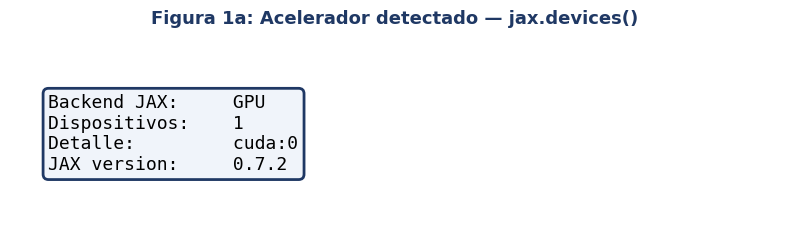

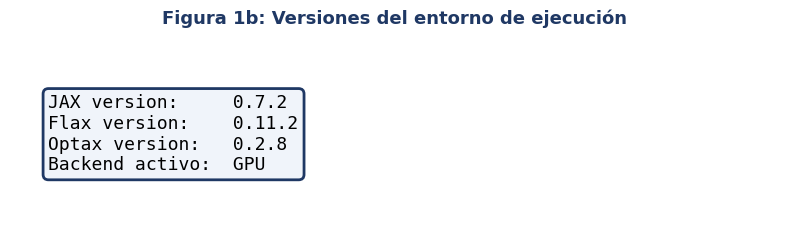

Guardados: acelerador_01_dispositivos.png y acelerador_02_versiones.png


In [35]:
import jax, flax, optax
import matplotlib.pyplot as plt

# ── Captura 1: dispositivos JAX ──
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis('off')
info = (
    f"Backend JAX:     {jax.default_backend().upper()}\n"
    f"Dispositivos:    {len(jax.devices())}\n"
    f"Detalle:         {jax.devices()[0]}\n"
    f"JAX version:     {jax.__version__}"
)
ax.text(0.05, 0.5, info, transform=ax.transAxes, fontsize=13,
        fontfamily='monospace', va='center',
        bbox=dict(boxstyle='round', facecolor='#f0f4fa', edgecolor='#1F3864', linewidth=2))
ax.set_title('Figura 1a: Acelerador detectado — jax.devices()', fontsize=13,
             fontweight='bold', color='#1F3864', pad=10)
plt.tight_layout()
plt.savefig('/content/acelerador_01_dispositivos.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Captura 2: versiones del entorno ──
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis('off')
info2 = (
    f"JAX version:     {jax.__version__}\n"
    f"Flax version:    {flax.__version__}\n"
    f"Optax version:   {optax.__version__}\n"
    f"Backend activo:  {jax.default_backend().upper()}"
)
ax.text(0.05, 0.5, info2, transform=ax.transAxes, fontsize=13,
        fontfamily='monospace', va='center',
        bbox=dict(boxstyle='round', facecolor='#f0f4fa', edgecolor='#1F3864', linewidth=2))
ax.set_title('Figura 1b: Versiones del entorno de ejecución', fontsize=13,
             fontweight='bold', color='#1F3864', pad=10)
plt.tight_layout()
plt.savefig('/content/acelerador_02_versiones.png', dpi=150, bbox_inches='tight')
plt.show()

print("Guardados: acelerador_01_dispositivos.png y acelerador_02_versiones.png")